In [1]:
import firedrake
import numpy as np
import pickle as pkl
from numpy import pi as π
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import firedrake
from firedrake import Constant, inner, sqrt, tr, grad, div, as_vector, exp,sym, as_vector, dx, ds, Mesh, Function, project, TransferManager
import meshpy, meshpy.geometry, meshpy.triangle
import irksome
from irksome import Dt
from scipy.signal import detrend
import copy
import matplotlib
import irksome
from irksome import Dt
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import pickle as pkl
import tqdm
import emcee
import corner
import itertools
import xarray
import dtscalibration
import glob
from rasterio.plot import show
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import os
import sys
from pyproj import Transformer
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from scripts.AH_temp_funcs import *
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import shapefile as sf

import rasterio
from rasterio.enums import Resampling
from rasterio.mask import mask

from firedrake.checkpointing import DumbCheckpoint

from firedrake import *


### Import our homemade functions ###
import scripts.model_modules
from scripts.mesh_generating import *

%matplotlib widget

# 1. Load the necessary data

### 1.1 Borehole locations

In [2]:
### Load boreholes
borehole_locations = pd.read_csv('Borehole_Locations/Borehole_locations_DTS.csv')
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3031", always_xy=True)
transformed_x, transformed_y = transformer.transform(borehole_locations['E'], borehole_locations['S'])

### 1.2 LIMA image

In [3]:
with rasterio.open('imagery/LIMA_virtual_Mosaic_15m.tif') as src1:
    image_data = src1.read()

### 1.3 GPS velocities

In [4]:
gps_velocities = pd.read_csv('GPS_velocities/24-25_velocities-good.csv')
apres_points = pd.read_csv('ApRES/apres_points.csv')

#### Outline of the area of the good dem

In [5]:
### Load the outline of the good dem

with rasterio.open('Meshes/good_dem_outline/ian_bed_outline_raster_full.tif') as src_good_dem:
    good_dem_filter = src_good_dem.read(2)

# Do the meshing

In [6]:
upscale_factor_fine = 1/10
src_bed_fine_path = "Meshes/crop_aoi/main_boreholes_aoi/main_boreholes_aoi_fix_bed.tif"
src_surf_fine_path = "Meshes/crop_aoi/main_boreholes_aoi/main_boreholes_aoi_fix_surf.tif"
layer_num=5

In [7]:
mesh_fine = mesh_creator(src_bed_fine_path, src_surf_fine_path, resamp_factor=upscale_factor_fine, layers=layer_num)
mesh_fine.tolerance = 1e-10
x_src, y_src, z_src = SpatialCoordinate(mesh_fine)

pressure_space = firedrake.FunctionSpace(mesh_fine, "CG", 1)
velocity_space = firedrake.VectorFunctionSpace(mesh_fine, "CG", 3)
Y = velocity_space * pressure_space
flow = firedrake.Function(Y)

chk = DumbCheckpoint("Saved_Models/fine_mesh_flow_80.0m_updated_viscosity", mode=FILE_READ)
chk.load(flow, name="fine_mesh_flow")

/opt/firedrake/firedrake/checkpointing.py:103: DeprecationWarning: DumbCheckpoint class will soon be deprecated; use CheckpointFile class instead.
  warnings.warn("DumbCheckpoint class will soon be deprecated; use CheckpointFile class instead.",


# Load the cross section we want

In [8]:
flowline_surf = pd.read_csv('flowlines/old_ice_flowlines/ALHIC1902_R_surface_nunatak_test_100m_test_case_4.csv')
flowline_bed = pd.read_csv('flowlines/old_ice_flowlines/ALHIC1902_R_bed_nunatak_test_100m_test_case_4.csv')
flowline_xs = flowline_surf['E']
flowline_ys = flowline_surf['N']
flowline_bed_elev = flowline_bed['Elev']
flowline_surf_elev = flowline_surf['Elev']
flowline_distance = flowline_surf['Distance']

### Upsample the flowline

In [9]:
upsampled_flowline_xs = []
upsampled_flowline_ys = []

for n in range(len(flowline_xs)-1):
    xs = np.array([flowline_xs[n], flowline_xs[n+1]])
    ys = np.array([flowline_ys[n], flowline_ys[n+1]])
    distance = np.sqrt((flowline_xs[n+1] - flowline_xs[n])**2 + (flowline_ys[n+1] - flowline_ys[n])**2)
    n_points = int(distance/80) + 1

    f = scipy.interpolate.interp1d(xs, ys)
    flowline_xs_new = np.linspace(xs[0], xs[1], n_points)
    flowline_ys_new = f(flowline_xs_new)

    upsampled_flowline_xs.append(flowline_xs_new)
    upsampled_flowline_ys.append(flowline_ys_new)

upsampled_flowline_xs = [x for xs in upsampled_flowline_xs for x in xs]
upsampled_flowline_ys = [x for xs in upsampled_flowline_ys for x in xs]

upsampled_flowline_xs = np.array(upsampled_flowline_xs).flatten()
upsampled_flowline_ys = np.array(upsampled_flowline_ys).flatten()

In [10]:
z_coords = np.arange(1000,2200, 1)

In [18]:
vel_prof=[]
u_prof = []
v_prof = []
w_prof = []
distances = []
zs = []
for n in range(len(upsampled_flowline_xs)):
    u_prof_step = []
    v_prof_step = []
    w_prof_step = []
    distance_step = []
    zs_step = []
    for z_coord in z_coords:
        try:
            velocity = flow.at(upsampled_flowline_xs[n], upsampled_flowline_ys[n], z_coord)[0]*spy*1000
            vel_prof.append(velocity)
            u_prof_step.append(velocity[0])
            v_prof_step.append(velocity[1])
            w_prof_step.append(velocity[2])
            distance = np.sqrt((upsampled_flowline_xs[n]-upsampled_flowline_xs[0])**2 + (upsampled_flowline_ys[n]-upsampled_flowline_ys[0])**2)
            distance_step.append(distance)
            zs_step.append(z_coord)


        except:
            u_prof_step.append(np.nan)
            v_prof_step.append(np.nan)
            w_prof_step.append(np.nan)
            distance = np.sqrt((upsampled_flowline_xs[n]-upsampled_flowline_xs[0])**2 + (upsampled_flowline_ys[n]-upsampled_flowline_ys[0])**2)
            distance_step.append(distance)
            zs_step.append(z_coord)
            continue

    u_prof.append(u_prof_step)
    v_prof.append(v_prof_step)
    w_prof.append(w_prof_step)
    distances.append(distance_step)
    zs.append(zs_step)


u_prof_arr = np.array(u_prof)
v_prof_arr = np.array(v_prof)
w_prof_arr = np.array(w_prof)
distances_arr = np.array(distances)
zs_arr = np.array(zs)

In [ ]:
# fig, axes = plt.subplots(3, 1, figsize=(10,10))
# vm = np.abs(u_prof.max()+30)
# cu = axes[0].tricontourf(vel_prof_coords[:,0], vel_prof_coords[:,1], u_prof, levels=30,vmin=-vm,vmax=vm, cmap='coolwarm')
# vm = np.abs(v_prof.max()+30)
# cv = axes[1].tricontourf(vel_prof_coords[:,0], vel_prof_coords[:,1], v_prof, levels=30,vmin=-vm,vmax=vm, cmap='coolwarm')
# vm = np.abs(z_prof.max()-20)
# cw = axes[2].tricontourf(vel_prof_coords[:,0], vel_prof_coords[:,1], z_prof, levels=30,vmin=-vm,vmax=vm, cmap='coolwarm')

# # Colorbars
# fig.colorbar(cu, ax=axes[0], label='u (mm/yr)')
# fig.colorbar(cv, ax=axes[1], label='v (mm/yr)')
# fig.colorbar(cw, ax=axes[2], label='w (mm/yr)')

# axes[0].set_ylabel('Elevation (m)')
# axes[1].set_ylabel('Elevation (m)')
# axes[2].set_ylabel('Elevation (m)')

# axes[2].set_xlabel('Distance (m)')

# axes[0].set_xlim([0,3000])
# axes[1].set_xlim([0,3000])
# axes[2].set_xlim([0,3000])

# # axes[0].set_ylim([1600,1950])
# # axes[1].set_ylim([1600,1900])
# # axes[2].set_ylim([1600,1950])

# plt.tight_layout()

/tmp/ipykernel_1419087/3813346050.py:4: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im_u = axes[0].pcolormesh(distances_arr.T, zs_arr.T, u_prof_arr.T, cmap='coolwarm', vmin=-vm, vmax=vm)
/tmp/ipykernel_1419087/3813346050.py:7: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im_v = axes[1].pcolormesh(distances_arr.T, zs_arr.T, v_prof_arr.T, cmap='coolwarm', vmin=-vm, vmax=vm)
/tmp/ipykernel_1419087/3813346050.py:10: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calcul

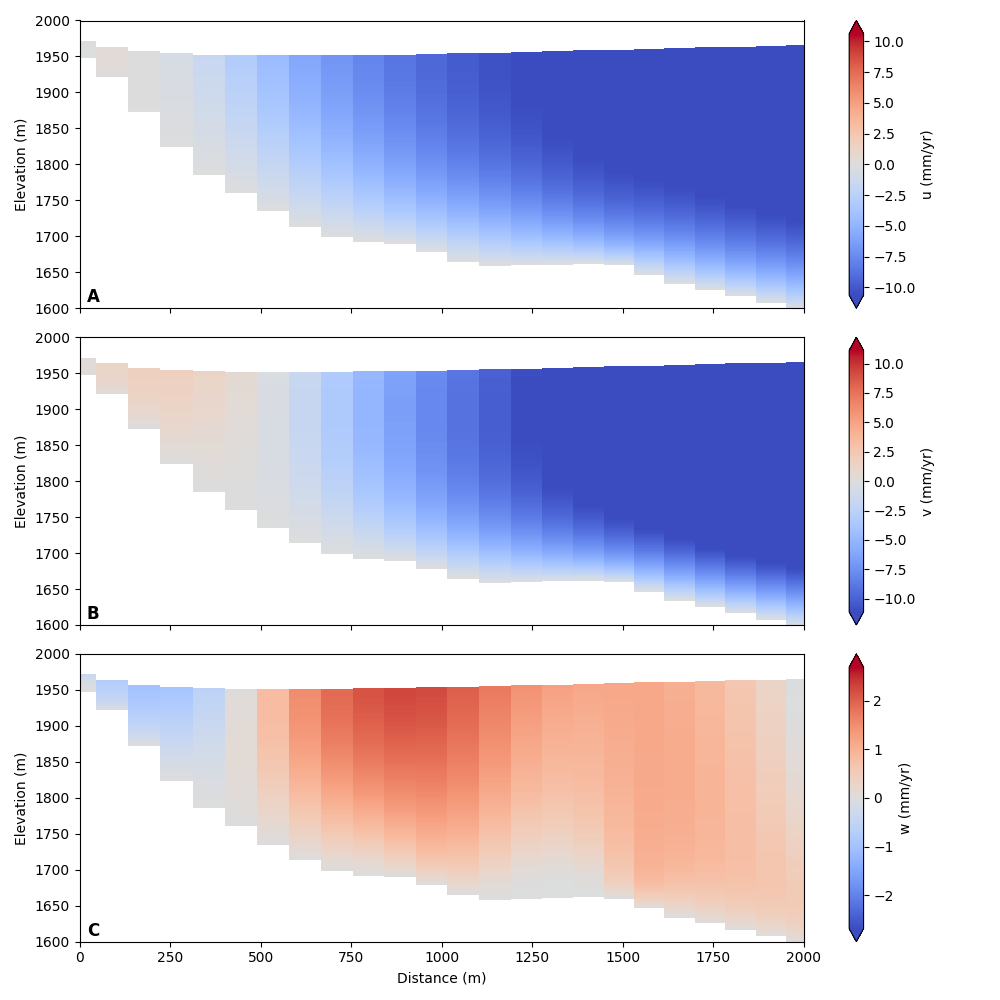

In [68]:
fig, axes = plt.subplots(3, 1, figsize=(10,10), sharex=True)

vm = np.nanmax(np.abs(u_prof_arr))-25
im_u = axes[0].pcolormesh(distances_arr.T, zs_arr.T, u_prof_arr.T, cmap='coolwarm', vmin=-vm, vmax=vm)

vm = np.nanmax(np.abs(v_prof_arr))-90
im_v = axes[1].pcolormesh(distances_arr.T, zs_arr.T, v_prof_arr.T, cmap='coolwarm', vmin=-vm, vmax=vm)

vm = np.nanmax(np.abs(w_prof_arr))-40
im_w = axes[2].pcolormesh(distances_arr.T, zs_arr.T, w_prof_arr.T, cmap='coolwarm', vmin=-vm, vmax=vm)

# Colorbars
fig.colorbar(im_u, ax=axes[0], label='u (mm/yr)', extend='both')
fig.colorbar(im_v, ax=axes[1], label='v (mm/yr)', extend='both')
fig.colorbar(im_w, ax=axes[2], label='w (mm/yr)', extend='both')

axes[0].set_xlim([0,2000])
axes[1].set_xlim([0,2000])
axes[2].set_xlim([0,2000])

axes[0].set_ylim([1600,2000])
axes[1].set_ylim([1600,2000])
axes[2].set_ylim([1600,2000])

axes[0].set_ylabel('Elevation (m)')
axes[1].set_ylabel('Elevation (m)')
axes[2].set_ylabel('Elevation (m)')

axes[2].set_xlabel('Distance (m)')

axes[0].annotate('A', (0.01,0.02), xycoords='axes fraction', fontsize=12, weight='bold')
axes[1].annotate('B', (0.01,0.02), xycoords='axes fraction', fontsize=12, weight='bold')
axes[2].annotate('C', (0.01,0.02), xycoords='axes fraction', fontsize=12, weight='bold')

plt.tight_layout()

plt.savefig('Figures/fig4_v3.png', dpi=600)
plt.savefig('Figures/fig4_v3.eps', dpi=600)
